In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv('imdb_top_movies_1980_2026.csv')

In [4]:
df.head()

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692


In [5]:
df.tail()

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
16247,tt3544218,Belgica,Belgica,2016,127.0,Drama,6.7,5001,https://www.imdb.com/title/tt3544218
16248,tt0101733,Dil Hai Ki Manta Nahin,Dil Hai Ki Manta Nahin,1991,154.0,"Adventure,Comedy,Drama",7.2,5001,https://www.imdb.com/title/tt0101733
16249,tt10994688,The Binge,The Binge,2020,98.0,Comedy,5.3,5000,https://www.imdb.com/title/tt10994688
16250,tt0263743,Billionaire,Milyarder,1987,96.0,"Comedy,Drama",7.5,5000,https://www.imdb.com/title/tt0263743
16251,tt1921078,Saint Petersburg,San Peterzburg,2010,120.0,"Comedy,Crime,Drama",6.4,5000,https://www.imdb.com/title/tt1921078


In [6]:
df.sample(5)

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
8837,tt19811010,The Remarkable Life of Ibelin,Ibelin,2024,103.0,"Animation,Biography,Documentary",8.1,14895,https://www.imdb.com/title/tt19811010
14737,tt6333052,Casting JonBenet,Casting JonBenet,2017,80.0,"Crime,Documentary,Drama",6.1,5993,https://www.imdb.com/title/tt6333052
8107,tt1016075,Fame,Fame,2009,107.0,"Drama,Musical,Romance",5.0,17356,https://www.imdb.com/title/tt1016075
361,tt1355644,Passengers,Passengers,2016,116.0,"Drama,Romance,Sci-Fi",7.0,495659,https://www.imdb.com/title/tt1355644
3696,tt19500164,Nimona,Nimona,2023,101.0,"Action,Adventure,Animation",7.5,61888,https://www.imdb.com/title/tt19500164


In [7]:
df.shape

(16252, 9)

In [8]:
df.columns

Index(['imdb_id', 'title', 'original_title', 'year', 'runtime_minutes',
       'genres', 'average_rating', 'num_votes', 'imdb_url'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16252 entries, 0 to 16251
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16252 non-null  object 
 1   title            16252 non-null  object 
 2   original_title   16252 non-null  object 
 3   year             16252 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16246 non-null  object 
 6   average_rating   16252 non-null  float64
 7   num_votes        16252 non-null  int64  
 8   imdb_url         16252 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 1.1+ MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,16252.0,2008.790118,11.581006,1980.0,2001.0,2011.0,2018.00,2026.0
runtime_minutes,16251.0,109.147376,22.110801,43.0,94.0,104.0,119.00,566.0
average_rating,16252.0,6.395194,1.050908,1.0,5.8,6.5,7.10,9.3
num_votes,16252.0,66331.718189,155736.555537,5000.0,8397.5,17266.0,53867.25,3182733.0


In [12]:
df.describe(include="object").T

,count,unique,top,freq
imdb_id,16252,16252,tt0111161,1
title,16252,15629,Brothers,4
original_title,16252,15811,Virus,3
genres,16246,505,"Comedy,Drama,Romance",760
imdb_url,16252,16252,https://www.imdb.com/title/tt0111161,1


In [13]:
df.isna().sum()

imdb_id            0
title              0
original_title     0
year               0
runtime_minutes    1
genres             6
average_rating     0
num_votes          0
imdb_url           0
dtype: int64

In [15]:
(df.isna().sum()/len(df))*100

imdb_id            0.000000
title              0.000000
original_title     0.000000
year               0.000000
runtime_minutes    0.006153
genres             0.036919
average_rating     0.000000
num_votes          0.000000
imdb_url           0.000000
dtype: float64

In [16]:
df.duplicated().sum()

0

In [18]:
df["decade"] = (df["year"]//10)*10

In [19]:
df["num_genres"] = (
    df["genres"]
    .fillna("")
    .str.split(",")
    .apply(len)
)

In [20]:
df.head()

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url,decade,num_genres
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161,1990,1
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569,2000,3
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666,2010,3
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523,1990,3
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692,2010,3


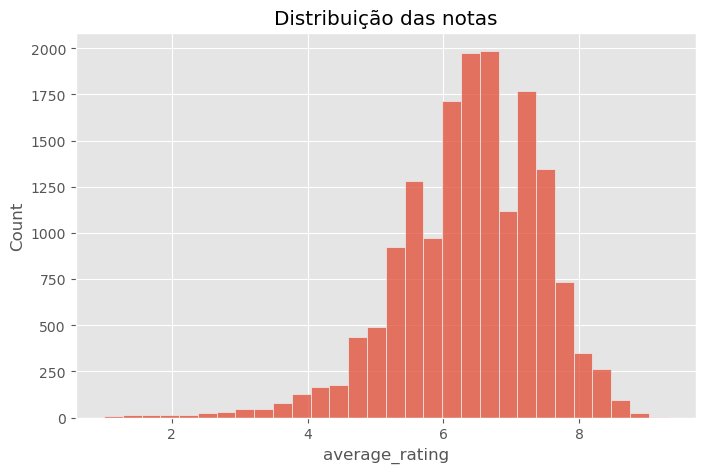

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["average_rating"], bins=30)

plt.title("Distribuição das notas")
plt.show()

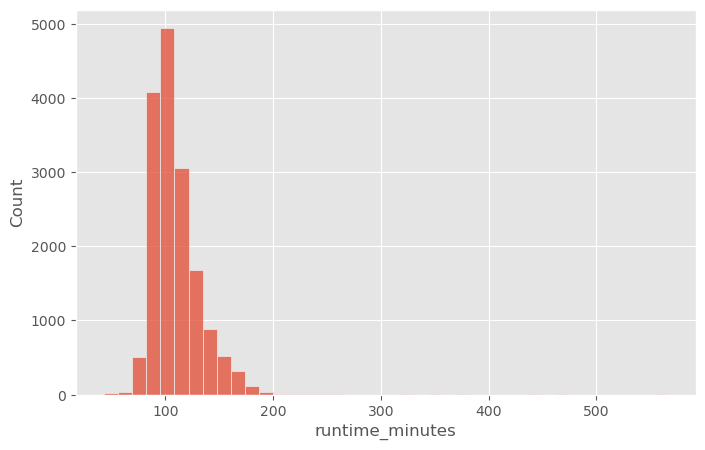

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["runtime_minutes"], bins=40)

plt.show()

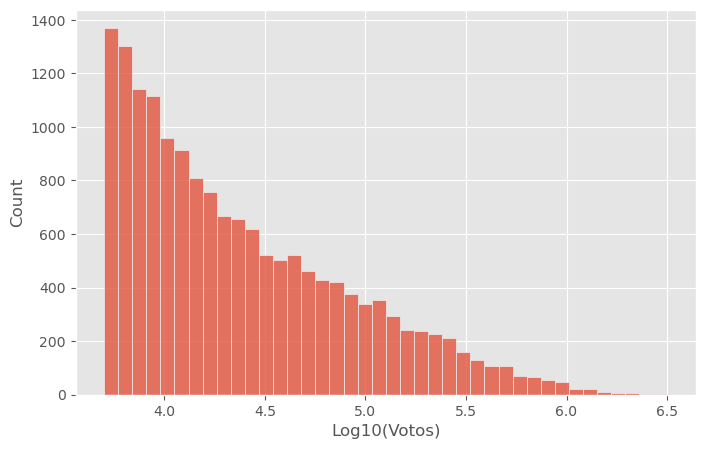

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(np.log10(df["num_votes"]+1), bins=40)

plt.xlabel("Log10(Votos)")
plt.show()

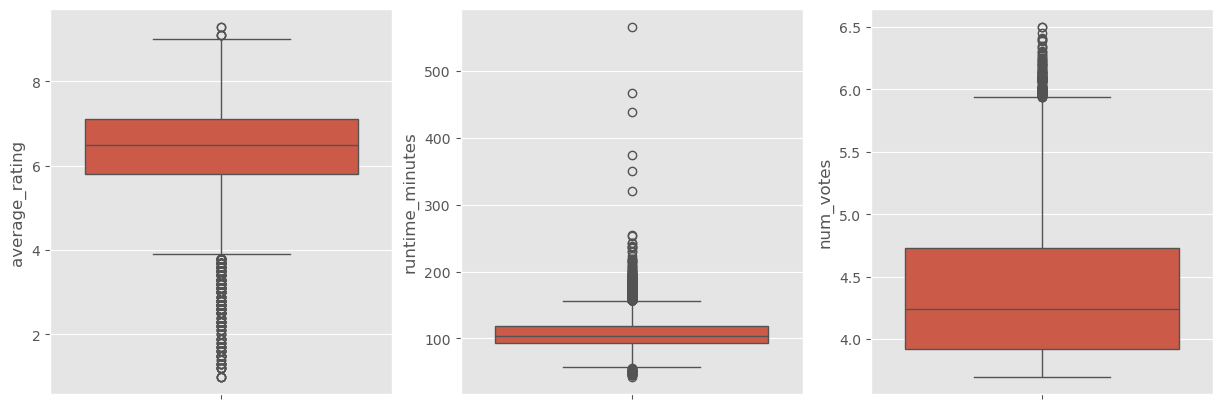

In [24]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(y=df["average_rating"], ax=axes[0])

sns.boxplot(y=df["runtime_minutes"], ax=axes[1])

sns.boxplot(y=np.log10(df["num_votes"]), ax=axes[2])

plt.show()

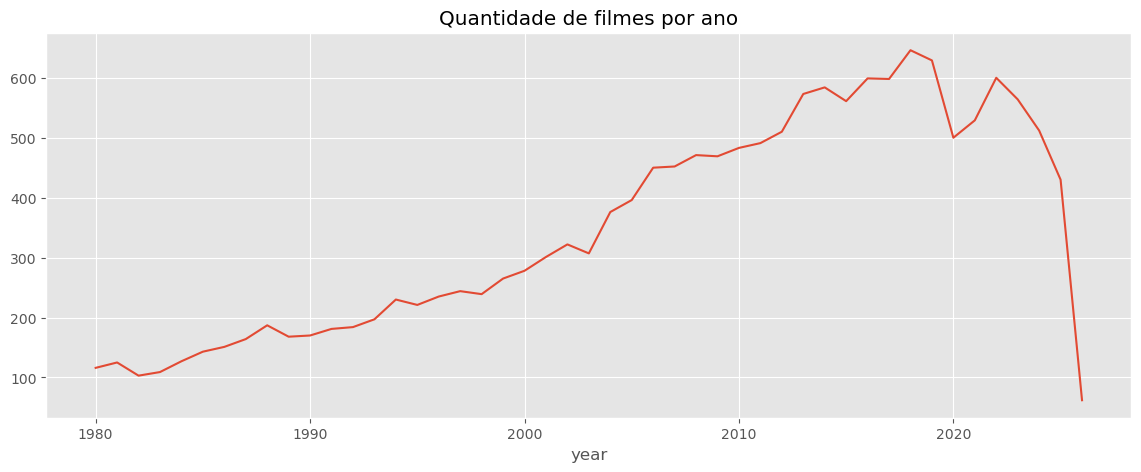

In [25]:
movies_year = (
    df
    .groupby("year")
    .size()
)

plt.figure(figsize=(14,5))

movies_year.plot()

plt.title("Quantidade de filmes por ano")

plt.show()

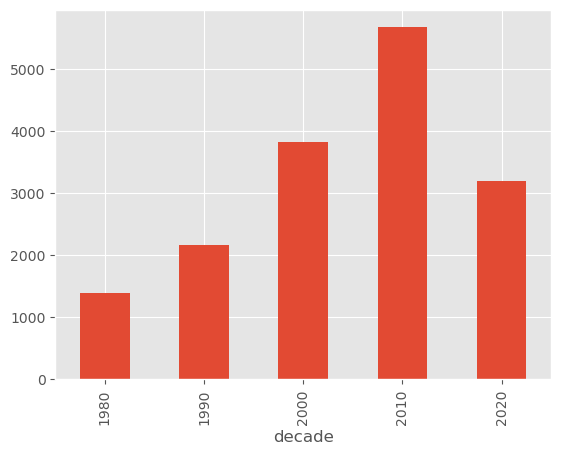

In [26]:
movies_decade = df["decade"].value_counts().sort_index()

movies_decade.plot(kind="bar")

plt.show()

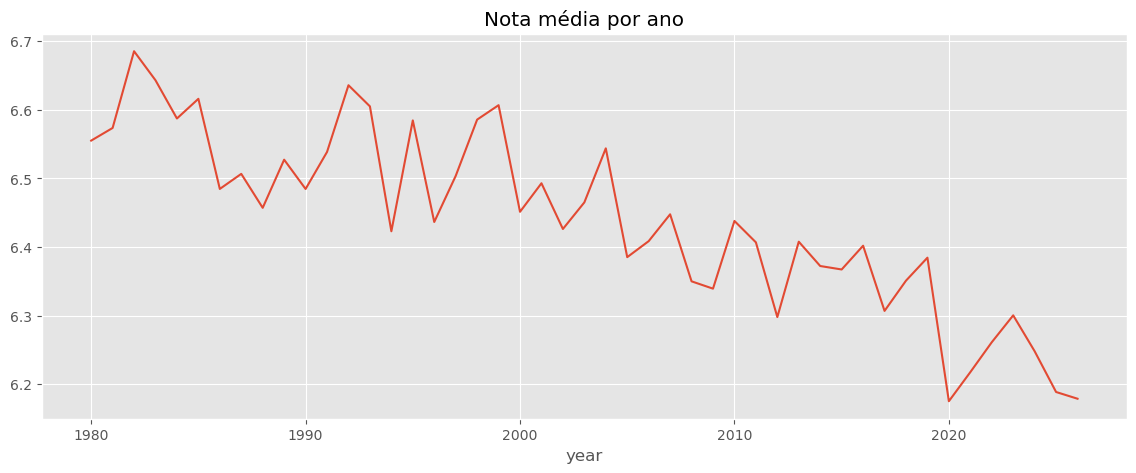

In [28]:
rating_year = (
    df
    .groupby("year")["average_rating"]
    .mean()
)

plt.figure(figsize=(14,5))

rating_year.plot()

plt.title("Nota média por ano")

plt.show()

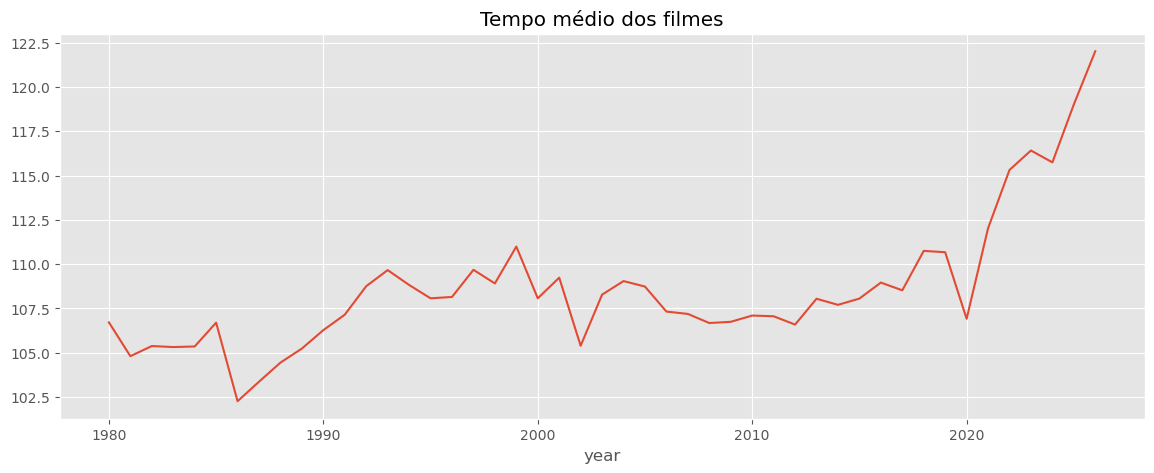

In [29]:
runtime = (
    df
    .groupby("year")["runtime_minutes"]
    .mean()
)

runtime.plot(figsize=(14,5))

plt.title("Tempo médio dos filmes")

plt.show()

In [30]:
genres = (
    df["genres"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

genres.value_counts().head(20)

genres
Drama          9219
Comedy         5874
Action         3941
Crime          3256
Thriller       2776
Romance        2652
Adventure      2337
Horror         2193
Mystery        1754
Biography      1130
Fantasy        1091
Sci-Fi          963
Animation       751
Family          659
History         628
Documentary     558
Music           515
Sport           354
War             289
Musical         176
Name: count, dtype: int64

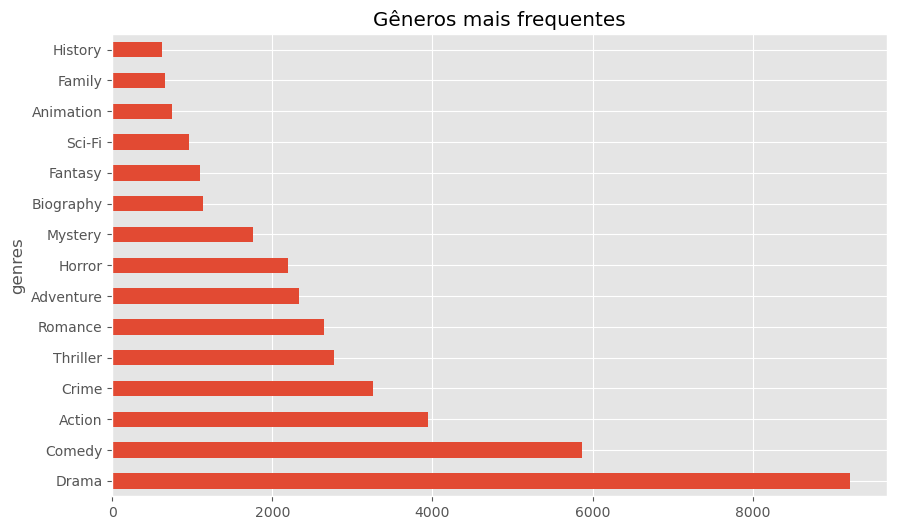

In [31]:
genres.value_counts().head(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Gêneros mais frequentes")

plt.show()

In [32]:
genre_df = df.copy()

genre_df["genres"] = genre_df["genres"].str.split(",")

genre_df = genre_df.explode("genres")

genre_df["genres"] = genre_df["genres"].str.strip()

In [33]:
genre_rating = (
    genre_df
    .groupby("genres")["average_rating"]
    .mean()
    .sort_values(ascending=False)
)

genre_rating.head(20)

genres
News           7.757143
Documentary    7.342294
Biography      7.001770
History        6.987261
War            6.967128
Animation      6.767776
Music          6.714563
Musical        6.646591
Sport          6.637571
Drama          6.634342
Western        6.480822
Crime          6.465233
Romance        6.442572
Adventure      6.280702
Comedy         6.267467
Action         6.192438
Mystery        6.157355
Family         6.143854
Fantasy        6.141063
Thriller       6.132817
Name: average_rating, dtype: float64

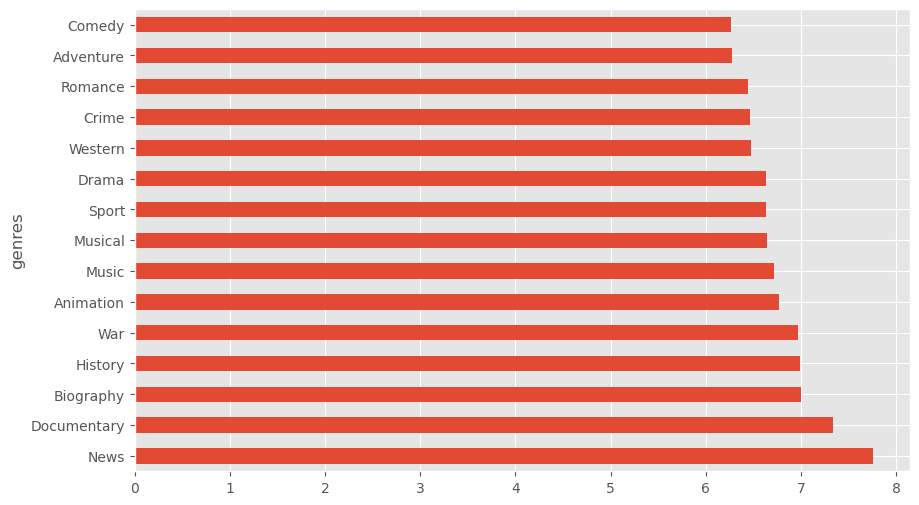

In [35]:
genre_rating.head(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.show()

In [37]:
df.nlargest(
    20,
    "num_votes"
)[
    [
        "title",
        "year",
        "average_rating",
        "num_votes"
    ]
]

,title,year,average_rating,num_votes
0,The Shawshank Redemption,1994,9.3,3182733
1,The Dark Knight,2008,9.1,3161984
2,Inception,2010,8.8,2811692
3,Fight Club,1999,8.8,2601984
4,Interstellar,2014,8.7,2521607
5,Forrest Gump,1994,8.8,2492584
6,Pulp Fiction,1994,8.8,2431723
7,The Matrix,1999,8.7,2243917
8,The Lord of the Rings: The Fellowship of the Ring,2001,8.9,2203274
9,The Lord of the Rings: The Return of the King,2003,9.0,2161551
